In [98]:
from InSitu14CO import Propagator
import numpy as np
import matplotlib.pyplot as plt
import crflux.models as pm
import matplotlib.ticker as ticker
import matplotlib as mpl
import Functions_14CO as F

from tqdm import tqdm

import pandas as pd

from scipy import stats 

from time import time

In [2]:
Prop = Propagator(elev=0)
Prop.set_H(0) #sets atmospheric depth to sea level (for calculations which use hg/cm^2)

In [3]:
Prop.load_ice_profile('Real_vs_ice_eq_depth.csv', 'DomeC_age_scale_Apr2023.csv')

In [4]:
Prop.set_energy_bins(logE_min = -1, logE_max = 11, logE_mu_max=7.5, dlogE=0.1)

In [5]:
Prop.set_zenith_bins(N_ang=10)

In [6]:
df_Pfast = pd.read_csv('Production Rates/P_fast_0m.csv')
df_Pneg = pd.read_csv('Production Rates/P_neg_0m.csv')
P_14C = np.swapaxes([df_Pfast.T, df_Pneg.T], 0, 1)
model_names = list(df_Pfast.columns)

In [7]:
Prop.Phi['prod']=P_14C
C_flow = F.flow_14C(Prop)

100%|█████████████████████████████████████████████████████████████████████████████| 7283/7283 [00:28<00:00, 252.06it/s]


In [8]:
t_scale = (Prop.t[Prop.i_start:]-Prop.t[-1])/(Prop.t[-1]-Prop.t[Prop.i_start])
f_lin = t_scale

In [9]:
da = 0.01
a = np.arange(-1,1+da, da)
a_weights = np.ones(len(a))

In [10]:
C_flow_lin = F.flow_14C(Prop, f_lin)

100%|█████████████████████████████████████████████████████████████████████████████| 7283/7283 [00:28<00:00, 257.99it/s]


In [11]:
df = pd.read_csv('14CO_f_all_ChiSq.csv')

In [12]:
C_pred = C_flow @ Prop.S_mat[Prop.i_start:]
C_weights = np.ones(len(C_pred))

f_factors = np.array([df['fast'],df['f_neg']]).T[1:]
f_weights = np.array(np.exp(-df['Chi_sq']/2))[1:] # convert chi^2 to prior weight

f_pure_avg = np.average(f_factors, weights=f_weights, axis=0)
C_norm = np.sum(f_pure_avg @ C_flow * Prop.dh[Prop.i_start:], axis=-1)

C_pred = C_pred / np.reshape(C_norm, (-1,1,1))
f_factors = f_factors * C_norm[-1]

In [13]:
C_lin = C_flow_lin @ Prop.S_mat[Prop.i_start:] / np.reshape(C_norm, (-1,1,1))

In [14]:
C_avg = np.average(C_pred, weights=C_weights, axis=0)
# axis0 - Production Mode
# axis1 - Sample Depth

#C_cov = np.reshape(
    #np.cov(np.reshape(C_pred, (len(C_pred), -1)), rowvar=False, aweights=C_weights),
    #(*np.shape(C_avg), *np.shape(C_avg)))
C_cov = np.zeros((2, len(Prop.z_samp), 2, len(Prop.z_samp)))
# axis0 - Production Mode A
# axis1 - Sample Depth A
# axis2 - Production Mode B
# axis3 - Sample Depth B

f_avg = np.average(f_factors, weights=f_weights, axis=0)
# axis0 - Production Mode

f_cov = np.cov(f_factors, rowvar=False, aweights=f_weights)
# axis0 - Production Mode A
# axis1 - Production Mode B

CO_avg = f_avg @ C_avg
# axis0 - Sample Depth

CO_cov = f_avg @ np.moveaxis(C_cov, (0,2), (-2,-1)) @ f_avg + C_avg.T @ f_cov @ C_avg + np.sum(C_cov * np.reshape(f_cov, (2,1,2,1)), axis=(0,2))
# axis0 - Sample Depth A
# axis1 - Sample Depth B

rel_err = 0.02 * np.ones(len(CO_avg))
# axis0 - Sample Depth

s_cov = np.diag(rel_err**2)
# axis0 - Sample Depth A
# axis1 - Sample Depth B

CO_samp_cov = CO_cov * (1+s_cov) + np.reshape(CO_avg, (-1,1)) * np.reshape(CO_avg, (1,-1)) * s_cov
# axis0 - Sample Depth A
# axis1 - Sample Depth B

CO_samp_cov_inv = np.linalg.inv(CO_samp_cov)

In [15]:
C_avg_lin = np.average(C_lin, weights=C_weights, axis=0)
CO_avg_lin = f_avg @ C_avg_lin

In [16]:
Sigma_f = np.reshape(f_avg@C_pred, (len(C_pred), -1, 1)) * np.reshape(f_avg@C_pred, (len(C_pred), 1, -1)) * s_cov  + np.swapaxes(C_pred, -2,-1) @ f_cov @ C_pred * (1+s_cov)

In [17]:
Sigma_f_inv = np.linalg.inv(Sigma_f)

In [18]:
def T(A):
    return np.swapaxes(A, -2, -1)

In [19]:
C_var = np.reshape(C_pred, (len(C_pred), 1, 2, -1)) + np.reshape(a, (1,-1,1,1)) * np.reshape(C_lin, (len(C_lin),1,2,-1))
#axis0 - model
#axis1 - amplitude
#axis2 - production mode
#axis3 - sample depth

Sigma_f_lin = np.reshape(f_avg@C_var, (len(C_var), len(a), -1, 1)) * np.reshape(f_avg@C_var, (len(C_var), len(a), 1, -1)) * s_cov  + T(C_var) @ f_cov @ C_var * (1+s_cov)

In [20]:
Sigma_f_lin_inv = np.linalg.inv(Sigma_f_lin)

In [21]:
np.sqrt(np.linalg.det(2*np.pi*Sigma_f_lin))

array([[2.12552493e+03, 2.07497357e+03, 2.02549150e+03, ...,
        1.82713458e+00, 1.72285605e+00, 1.62370605e+00],
       [1.98923119e+03, 1.94250967e+03, 1.89676428e+03, ...,
        1.98970580e+00, 1.88012613e+00, 1.77575523e+00],
       [2.05207804e+03, 2.00367044e+03, 1.95627856e+03, ...,
        1.94976493e+00, 1.84108465e+00, 1.73763029e+00],
       ...,
       [2.17020776e+03, 2.11825003e+03, 2.06739852e+03, ...,
        1.71489708e+00, 1.61506450e+00, 1.52023563e+00],
       [2.17016976e+03, 2.11821329e+03, 2.06736301e+03, ...,
        1.71501878e+00, 1.61518120e+00, 1.52034748e+00],
       [2.11222210e+03, 2.06204942e+03, 2.01293668e+03, ...,
        1.83855528e+00, 1.73387461e+00, 1.63432928e+00]])

In [22]:
np.shape(Sigma_f_lin_inv)

(161, 201, 11, 11)

In [128]:
def get_probs(N=1000, a_samp=0):
    i = np.random.choice(np.arange(len(C_pred)), N, p=C_weights/np.sum(C_weights))
    j = np.random.choice(np.arange(len(f_factors)), N, p=f_weights/np.sum(f_weights))
    s = np.random.normal(0,rel_err,(N,len(CO_avg)))
    x = (np.reshape(f_factors[j], (-1,1,2))@(C_pred[i] + a_samp*C_lin[i]))[:,0]*(1+s)
    
    dCO_0 = np.reshape(x, (len(x),1,-1,1))-np.reshape(f_avg@C_pred, (1,len(C_pred),-1,1))
    P_0 = np.sum(np.exp(-T(dCO_0)@Sigma_f_inv@dCO_0/2)[:,:,0,0]*np.reshape(C_weights/np.sqrt(np.linalg.det(2*np.pi*Sigma_f)), (1,-1)), axis=-1)/np.sum(C_weights)
    
    dCO_var = np.reshape(x, (len(x),1,1,-1,1))-np.reshape(f_avg@C_var, (1,len(C_var),len(a),-1,1))
    P_lin = np.sum(np.exp(-T(dCO_var)@Sigma_f_lin_inv@dCO_var/2)[:,:,:,0,0]/np.reshape(np.sqrt(np.linalg.det(2*np.pi*Sigma_f_lin)), (1,len(C_var),-1))*np.reshape(a_weights, (1,1,-1))*np.reshape(C_weights, (1,-1,1)), axis=(1,2))/np.sum(a_weights)/np.sum(C_weights)
    
    return P_0, P_lin

In [107]:
#P = np.reshape(np.swapaxes([get_probs() for i in tqdm(range(10))], 0,1), (2,-1))

100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [01:04<00:00,  6.42s/it]


In [108]:
#P = [get_probs(100) for i in tqdm(range(100))]

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [01:12<00:00,  1.38it/s]


In [109]:
#P = [get_probs(10000) for i in tqdm(range(1))]

100%|███████████████████████████████████████████████████████████████████████████████████| 1/1 [03:32<00:00, 212.53s/it]


In [110]:
P = np.reshape(np.swapaxes([get_probs() for i in tqdm(range(100))], 0,1), (2,-1))

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [10:32<00:00,  6.32s/it]


In [111]:
B_01 = P[0]/P[1]

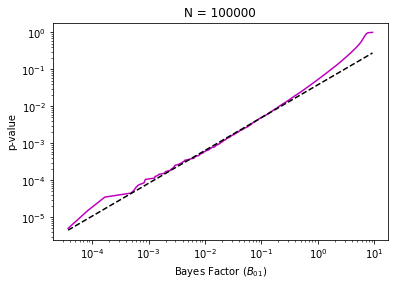

In [115]:
B = np.sort(B_01)
p = (np.arange(len(B_01))+0.5)/len(B_01)

coef = np.polyfit(np.log(B[:1000]),np.log(p[:1000]),1)
poly1d_fn = np.poly1d(coef) 
# poly1d_fn is now a function which takes in x and returns an estimate for y

plt.plot(B,p, '-m', B, np.exp(poly1d_fn(np.log(B))), '--k')
plt.xscale('log')
plt.xlabel(r'Bayes Factor ($B_{01}$)')
plt.yscale('log')
plt.ylabel('p-value')
plt.title('N = {}'.format(N))
plt.show()

In [116]:
coef

array([ 0.88927996, -3.25853574])

In [125]:
# ln(p) = coef[0]*ln(B) + coef[1]
# ln(B) = (ln(p)-coef[1])/coef[0]
sigs = [3,4,5]
B_thr = [np.exp((np.log(stats.norm.sf(s)*2)-coef[1])/coef[0]) for s in sigs]

In [127]:
[stats.norm.sf(s)*2 for s in sigs]

[0.002699796063260186, 6.334248366623973e-05, 5.733031437583867e-07]

In [126]:
B_thr

[0.05045190911869861, 0.0007418967639880689, 3.7379178356399663e-06]

In [130]:
P_var = np.swapaxes([get_probs(100, a_samp=a_samp) for a_samp in tqdm(a)], 0,1)

100%|████████████████████████████████████████████████████████████████████████████████| 201/201 [21:16<00:00,  6.35s/it]


In [131]:
B_var = P_var[0]/P_var[1]

In [139]:
discovery = np.array([np.sum(B_var<=b, axis=-1)/np.shape(B_var)[-1] for b in B_thr])

In [151]:
sensitivity_low = a[np.array([np.arange(len(discovery[i]))[discovery[i]<0.5][0]-1 for i in range(len(discovery))])]
sensitivity_high = a[np.array([np.arange(len(discovery[i]))[discovery[i]<0.5][-1]+1 for i in range(len(discovery))])]

[]

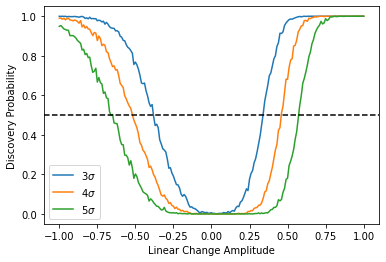

In [140]:
for i,d in enumerate(discovery):
    plt.plot(a, d, label=r'{}$\sigma$'.format(sigs[i]))
plt.axhline(0.5, c='k', ls='--')
plt.xlabel('Linear Change Amplitude')
plt.ylabel('Discovery Probability')
plt.legend()
plt.plot()

In [152]:
print(sensitivity_low)
print(sensitivity_high)

[-0.39 -0.52 -0.67]
[0.34 0.46 0.58]
